Diabetes Prediction Project

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import seaborn as sns
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
)

np.random.seed(42)
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

In [ ]:
diabetesData = "diabetes_binary_health_indicators_BRFSS2015.csv"

df = pd.read_csv(diabetesData)

In [41]:
dataTypes = df.dtypes
missingValues = df.isnull().sum()
duplicateRows = df.duplicated().sum()
targetDistribution = df['Diabetes_binary'].value_counts()/len(df) * 100
print("Data Types:\n", dataTypes)
print("Missing Values:\n", missingValues)
print("\nDuplicate Rows:", duplicateRows)
print("\nTarget Distribution:\n", targetDistribution)


Data Types:
 Diabetes_binary         float64
HighBP                  float64
HighChol                float64
CholCheck               float64
BMI                     float64
Smoker                  float64
Stroke                  float64
HeartDiseaseorAttack    float64
PhysActivity            float64
Fruits                  float64
Veggies                 float64
HvyAlcoholConsump       float64
AnyHealthcare           float64
NoDocbcCost             float64
GenHlth                 float64
MentHlth                float64
PhysHlth                float64
DiffWalk                float64
Sex                     float64
Age                     float64
Education               float64
Income                  float64
dtype: object
Missing Values:
 Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits            

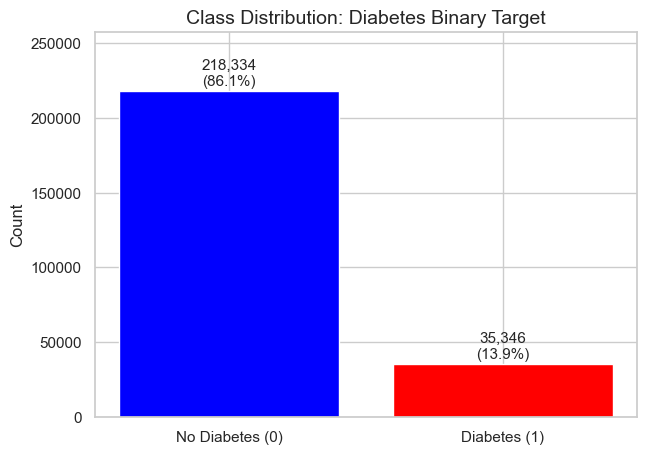

Saved: fig1_class_distribution.png


In [71]:
fig, ax = plt.subplots(figsize=(7, 5))

counts = df['Diabetes_binary'].value_counts().sort_index()
labels = ['No Diabetes (0)', 'Diabetes (1)']
colors = ['blue', 'red']

bars = ax.bar(labels, counts.values, color=colors, edgecolor='white')

for bar, count in zip(bars, counts.values):
    pct = count / len(df) * 100
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1500,
            f'{count:,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=11)

ax.set_title('Class Distribution: Diabetes Binary Target', fontsize=14)
ax.set_ylabel('Count', fontsize=12)
ax.set_ylim(0, counts.max() * 1.18)

plt.savefig('fig1_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fig1_class_distribution.png")


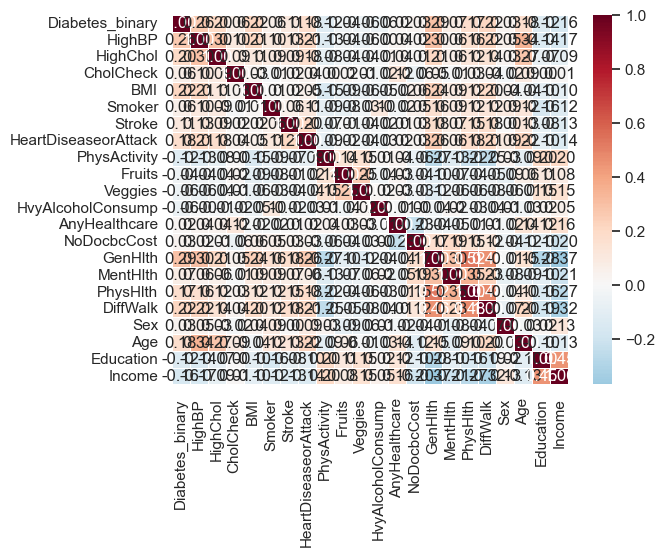

In [81]:
correlationMatrix = df.corr(method='pearson')
ax = sns.heatmap(correlationMatrix, annot=True, fmt=".2f", cmap='RdBu_r', center=0, linewidths=0.5)